# Sussex-Huawei Locomotion (SHL)

In [39]:
import pandas as pd
import numpy as np
import json
import os

import math

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

## Loading and preparing train and test data

### User 1 - Hand

Se proceden a leer los datos del Usuario 1, para las medidas del móvil en la mano, de los días:
- 220617
- 260617
- 270617

In [40]:
ruta_archivo_user1_csv = "Old Datasets/SHL/SHLDataset_preview_v1_part1/SHLDataset_preview_v1/User1/"
fechas = ["220617", "260617", "270617"]
hand_csv = "Hand_Motion.csv"
output_file = "Combined_Hand_Motion.csv"

In [41]:
# Crear una lista para almacenar los DataFrames de los archivos CSV
dataframes = []

# Iterar a través de las fechas y leer los archivos Hand_Motion.csv
for fecha in fechas:
    folder_path = os.path.join(ruta_archivo_user1_csv, fecha)
    file_path = os.path.join(folder_path, hand_csv)
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        dataframes.append(df)

# Unir los DataFrames en uno solo
user1_hand = pd.concat(dataframes, ignore_index=True)

# Guardar el DataFrame combinado en un archivo CSV
user1_hand.to_csv(output_file, index=False)

print(f"Datos combinados guardados en '{output_file}'.")

Datos combinados guardados en 'Combined_Hand_Motion.csv'.


### User 1 - Hips

Se proceden a leer los datos del Usuario 1, para las medidas del móvil cuando se encuentra en el bolsillo delantero del pantalón, de los días:
- 220617
- 260617
- 270617

In [42]:
hips_csv = "Hips_Motion.csv"
output_file = "Combined_Hips_Motion.csv"

In [43]:
# Crear una lista para almacenar los DataFrames de los archivos CSV
dataframes = []

# Iterar a través de las fechas y leer los archivos Hand_Motion.csv
for fecha in fechas:
    folder_path = os.path.join(ruta_archivo_user1_csv, fecha)
    file_path = os.path.join(folder_path, hips_csv)
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        dataframes.append(df)

# Unir los DataFrames en uno solo
user1_hips = pd.concat(dataframes, ignore_index=True)

# Guardar el DataFrame combinado en un archivo CSV
user1_hips.to_csv(output_file, index=False)

print(f"Datos combinados guardados en '{output_file}'.")

Datos combinados guardados en 'Combined_Hips_Motion.csv'.


### User 1 Labels

Al haberse realizado las mediciones de forma simultanea, se tiene un único fichero llamado Label, donde se encuentra toda la información de las etiquetas para las diferentes posiciones de móvil, por eso la leemos una sola vez

In [44]:
label_csv = "Label.csv"
output_label_file = "Combined_Label_Motion.csv"

# Crear una lista para almacenar los DataFrames de los archivos CSV
dataframes = []

# Iterar a través de las fechas y leer los archivos Label.csv
for fecha in fechas:
    folder_path = os.path.join(ruta_archivo_user1_csv, fecha)
    file_path = os.path.join(folder_path, label_csv)
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        dataframes.append(df)

# Unir los DataFrames en uno solo
user1_labels = pd.concat(dataframes, ignore_index=True)

# Guardar el DataFrame combinado en un archivo CSV
user1_labels.to_csv(output_label_file, index=False)

print(f"Datos combinados guardados en '{output_label_file}'.")

Datos combinados guardados en 'Combined_Label_Motion.csv'.


#### Unir Combined_Hand_Motion con Combined_Label_Motion

In [45]:
# Unir las tablas por la columna "Time"
user1hand = pd.merge(user1_hand, user1_labels, on="Time")

In [46]:
user1hand.head()

,Time,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,...,Pressure,Altitude,Temperature,Coarse,Fine,Road,Traffic,Tunnels,Social,Food
0,1.498120e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,0,0,0,0
1,1.498120e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,0,0,0,0
2,1.498120e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,0,0,0,0
3,1.498120e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,0,0,0,0
4,1.498120e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,0,0,0,0


#### Unir Combined_Hips_Motion con Combined_Label_Motion

In [47]:
# Unir las tablas por la columna "Time"
user1hips = pd.merge(user1_hips, user1_labels, on="Time")

In [48]:
user1hips.head()

,Time,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,...,Pressure,Altitude,Temperature,Coarse,Fine,Road,Traffic,Tunnels,Social,Food
0,1.498120e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,0,0,0,0
1,1.498120e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,0,0,0,0
2,1.498120e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,0,0,0,0
3,1.498120e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,0,0,0,0
4,1.498120e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,0,0,0,0,0


#### Filtrar las actividades que nos interesan

Se observa que la Columna "Coarse" indica los valores de las actividades que se están realizando:
- Null=0, Still=1, Walking=2, Run=3, Bike=4, Car=5, Bus=6, Train=7, Subway=8

Por lo tanto nos interesa quedarnos con los valores 1, 2, 5, 6 y 8. 

In [49]:
user1hand = user1hand.loc[(user1hand["Coarse"] == 1) | (user1hand["Coarse"] == 2) | (user1hand["Coarse"] == 5) | (user1hand["Coarse"] == 6) | (user1hand["Coarse"] == 8)]

In [50]:
user1hips = user1hips.loc[(user1hips["Coarse"] == 1) | (user1hips["Coarse"] == 2) | (user1hips["Coarse"] == 5) | (user1hips["Coarse"] == 6) | (user1hips["Coarse"] == 8)]

Procedemos a quedarnos con el 50% de los datos de las dos tablas:

In [51]:
user1hand = user1hand.sample(frac=0.5, random_state=42)
user1hips = user1hips.sample(frac=0.5, random_state=42)

#### Unir los dos datasets

In [52]:
user1 = pd.concat([user1hand, user1hips], ignore_index=True)
user1.head()

,Time,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,...,Pressure,Altitude,Temperature,Coarse,Fine,Road,Traffic,Tunnels,Social,Food
0,1.498151e+12,-0.112530,-9.480986,-5.858583,0.765418,-0.701886,-0.142948,-14.212495,65.100005,8.143725,...,1006.552045,0.0,0.0,2,5,0,0,0,0,0
1,1.498127e+12,-2.287726,1.215589,-9.987678,0.041404,-0.200028,0.012704,-2.090966,6.184403,34.562500,...,1003.728165,0.0,0.0,5,9,1,0,0,0,0
2,1.498137e+12,7.327576,-0.110329,3.072721,-0.025761,-0.024539,-0.023265,-11.653038,13.726345,32.655078,...,1000.561915,0.0,0.0,5,9,1,0,0,1,0
3,1.498497e+12,-7.067683,6.182720,-1.578391,0.038277,0.022785,-0.032584,15.919835,-37.742237,13.437500,...,1011.947161,0.0,0.0,1,4,0,0,0,1,0
4,1.498481e+12,1.472108,9.277263,2.885282,0.107542,-0.140924,0.047128,29.422116,-66.586541,-13.577884,...,1012.128025,0.0,0.0,6,11,1,0,0,0,0


In [53]:
user1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4561510 entries, 0 to 4561509
Data columns (total 30 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Time         float64
 1   Ax           float64
 2   Ay           float64
 3   Az           float64
 4   Gx           float64
 5   Gy           float64
 6   Gz           float64
 7   Mx           float64
 8   My           float64
 9   Mz           float64
 10  Ow           float64
 11  Ox           float64
 12  Oy           float64
 13  Oz           float64
 14  Gravx        float64
 15  Gravy        float64
 16  Gravz        float64
 17  LAx          float64
 18  LAy          float64
 19  LAz          float64
 20  Pressure     float64
 21  Altitude     float64
 22  Temperature  float64
 23  Coarse       int64  
 24  Fine         int64  
 25  Road         int64  
 26  Traffic      int64  
 27  Tunnels      int64  
 28  Social       int64  
 29  Food         int64  
dtypes: float64(23), int64(7)
memory usage: 1.0 GB


#### Calculo de valores no nulos

In [54]:
# Agrupar por la columna "Coarse" y calcular el número de datos no nulos por columna
counts = user1.groupby("Coarse").count()

# Calcular la suma de valores nulos por columna
null_counts = user1.groupby("Coarse").apply(lambda x: x.isnull().sum())

# Mostrar el número de datos no nulos
counts.head(20)

,Time,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,...,LAz,Pressure,Altitude,Temperature,Fine,Road,Traffic,Tunnels,Social,Food
Coarse,,,,,,,,,,,,,,,,,,,,,
1,867944,867944,867944,867944,867944,867944,867944,867944,867944,867944,...,867944,867944,867944,867944,867944,867944,867944,867944,867944,867944
2,804114,804114,804114,804114,804114,804114,804114,804114,804114,804114,...,804114,804114,804114,804114,804114,804114,804114,804114,804114,804114
5,993710,993710,993710,993710,993710,993710,993710,993710,993710,993710,...,993710,993710,993710,993710,993710,993710,993710,993710,993710,993710
6,983404,983404,983404,983404,983404,983404,983404,983404,983404,983404,...,983404,983404,983404,983404,983404,983404,983404,983404,983404,983404
8,912338,912338,912338,912338,912338,912338,912338,912338,912338,912338,...,912338,912338,912338,912338,912338,912338,912338,912338,912338,912338


# Preparamos los datos

#### Comprobación de las columnas del sensor Acelerómetro

In [55]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['Ax', 'Ay', 'Az']] = user1[['Ax', 'Ay', 'Az']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

,Time,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,...,Pressure,Altitude,Temperature,Coarse,Fine,Road,Traffic,Tunnels,Social,Food
0,1.498151e+12,-0.112530,-9.480986,-5.858583,0.765418,-0.701886,-0.142948,-14.212495,65.100005,8.143725,...,1006.552045,0.0,0.0,2,5,0,0,0,0,0
1,1.498127e+12,-2.287726,1.215589,-9.987678,0.041404,-0.200028,0.012704,-2.090966,6.184403,34.562500,...,1003.728165,0.0,0.0,5,9,1,0,0,0,0
2,1.498137e+12,7.327576,-0.110329,3.072721,-0.025761,-0.024539,-0.023265,-11.653038,13.726345,32.655078,...,1000.561915,0.0,0.0,5,9,1,0,0,1,0
3,1.498497e+12,-7.067683,6.182720,-1.578391,0.038277,0.022785,-0.032584,15.919835,-37.742237,13.437500,...,1011.947161,0.0,0.0,1,4,0,0,0,1,0
4,1.498481e+12,1.472108,9.277263,2.885282,0.107542,-0.140924,0.047128,29.422116,-66.586541,-13.577884,...,1012.128025,0.0,0.0,6,11,1,0,0,0,0


In [56]:
cantidad_nulos = user1[['Ax', 'Ay', 'Az']].isnull().sum()
print(cantidad_nulos)

Ax    0
Ay    0
Az    0
dtype: int64


#### Comprobación de las columnas del sensor Giroscopio

In [57]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['Gx', 'Gy', 'Gz']] = user1[['Gx', 'Gy', 'Gz']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

,Time,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,...,Pressure,Altitude,Temperature,Coarse,Fine,Road,Traffic,Tunnels,Social,Food
0,1.498151e+12,-0.112530,-9.480986,-5.858583,0.765418,-0.701886,-0.142948,-14.212495,65.100005,8.143725,...,1006.552045,0.0,0.0,2,5,0,0,0,0,0
1,1.498127e+12,-2.287726,1.215589,-9.987678,0.041404,-0.200028,0.012704,-2.090966,6.184403,34.562500,...,1003.728165,0.0,0.0,5,9,1,0,0,0,0
2,1.498137e+12,7.327576,-0.110329,3.072721,-0.025761,-0.024539,-0.023265,-11.653038,13.726345,32.655078,...,1000.561915,0.0,0.0,5,9,1,0,0,1,0
3,1.498497e+12,-7.067683,6.182720,-1.578391,0.038277,0.022785,-0.032584,15.919835,-37.742237,13.437500,...,1011.947161,0.0,0.0,1,4,0,0,0,1,0
4,1.498481e+12,1.472108,9.277263,2.885282,0.107542,-0.140924,0.047128,29.422116,-66.586541,-13.577884,...,1012.128025,0.0,0.0,6,11,1,0,0,0,0


In [58]:
cantidad_nulos = user1[['Gx', 'Gy', 'Gz']].isnull().sum()
print(cantidad_nulos)

Gx    0
Gy    0
Gz    0
dtype: int64


#### Comprobación de las columnas del sensor Magnetómetro

In [59]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['Mx', 'My', 'Mz']] = user1[['Mx', 'My', 'Mz']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

,Time,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,...,Pressure,Altitude,Temperature,Coarse,Fine,Road,Traffic,Tunnels,Social,Food
0,1.498151e+12,-0.112530,-9.480986,-5.858583,0.765418,-0.701886,-0.142948,-14.212495,65.100005,8.143725,...,1006.552045,0.0,0.0,2,5,0,0,0,0,0
1,1.498127e+12,-2.287726,1.215589,-9.987678,0.041404,-0.200028,0.012704,-2.090966,6.184403,34.562500,...,1003.728165,0.0,0.0,5,9,1,0,0,0,0
2,1.498137e+12,7.327576,-0.110329,3.072721,-0.025761,-0.024539,-0.023265,-11.653038,13.726345,32.655078,...,1000.561915,0.0,0.0,5,9,1,0,0,1,0
3,1.498497e+12,-7.067683,6.182720,-1.578391,0.038277,0.022785,-0.032584,15.919835,-37.742237,13.437500,...,1011.947161,0.0,0.0,1,4,0,0,0,1,0
4,1.498481e+12,1.472108,9.277263,2.885282,0.107542,-0.140924,0.047128,29.422116,-66.586541,-13.577884,...,1012.128025,0.0,0.0,6,11,1,0,0,0,0


In [60]:
cantidad_nulos = user1[['Mx', 'My', 'Mz']].isnull().sum()
print(cantidad_nulos)

Mx    0
My    0
Mz    0
dtype: int64


#### Comprobación de los sensores Barómetro 

In [61]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['Pressure']] = user1[['Pressure']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

,Time,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,...,Pressure,Altitude,Temperature,Coarse,Fine,Road,Traffic,Tunnels,Social,Food
0,1.498151e+12,-0.112530,-9.480986,-5.858583,0.765418,-0.701886,-0.142948,-14.212495,65.100005,8.143725,...,1006.552045,0.0,0.0,2,5,0,0,0,0,0
1,1.498127e+12,-2.287726,1.215589,-9.987678,0.041404,-0.200028,0.012704,-2.090966,6.184403,34.562500,...,1003.728165,0.0,0.0,5,9,1,0,0,0,0
2,1.498137e+12,7.327576,-0.110329,3.072721,-0.025761,-0.024539,-0.023265,-11.653038,13.726345,32.655078,...,1000.561915,0.0,0.0,5,9,1,0,0,1,0
3,1.498497e+12,-7.067683,6.182720,-1.578391,0.038277,0.022785,-0.032584,15.919835,-37.742237,13.437500,...,1011.947161,0.0,0.0,1,4,0,0,0,1,0
4,1.498481e+12,1.472108,9.277263,2.885282,0.107542,-0.140924,0.047128,29.422116,-66.586541,-13.577884,...,1012.128025,0.0,0.0,6,11,1,0,0,0,0


In [62]:
cantidad_nulos = user1[['Pressure']].isnull().sum()
print(cantidad_nulos)

Pressure    0
dtype: int64


#### Número de valores de cada Actividad

In [63]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = user1['Coarse'].value_counts()

# Imprimir el resultado
print(conteo_valores)

5    993710
6    983404
8    912338
1    867944
2    804114
Name: Coarse, dtype: int64


# Correlación de datos

In [64]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(user1.corr()['Coarse'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

Coarse         1.000000
Fine           0.968082
Food           0.542732
Tunnels        0.494609
Social         0.400872
Time           0.275780
Gravy          0.268976
Ay             0.265861
Ow             0.258543
Az             0.244673
Gravz          0.241781
Road           0.239249
Ox             0.140051
My             0.124037
Mz             0.068267
Oy             0.062176
Oz             0.061260
LAy            0.056402
LAx            0.051264
Ax             0.043590
Mx             0.042099
LAz            0.042061
Gravx          0.028727
Pressure       0.026339
Gz             0.015499
Gy             0.002930
Gx             0.001128
Altitude            NaN
Temperature         NaN
Traffic             NaN
Name: Coarse, dtype: float64


## Matríz de correlación

Text(0.5, 1.0, 'Correlation Matrix')

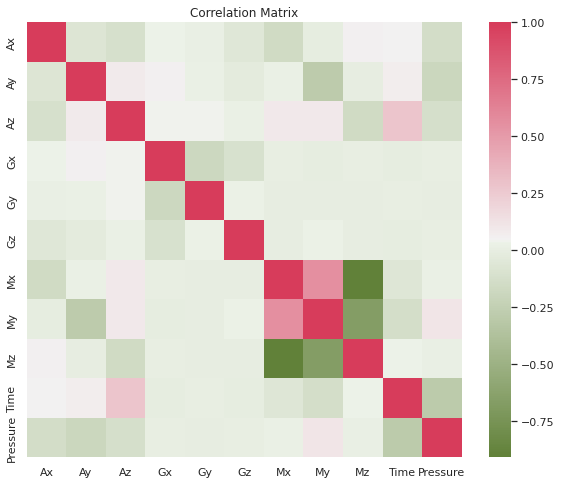

In [65]:
# Correlation matrix
CorrInfo = pd.DataFrame(user1,columns=["Ax","Ay","Az","Gx","Gy","Gz","Mx","My","Mz","Time", 'Pressure'])

f, ax = plt.subplots(figsize=(10, 8))
corr = CorrInfo.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(110, 5, as_cmap=True),
            square=True, ax=ax)
plt.title("Correlation Matrix")

In [66]:
#Square root of sum of squares of accelerometer, linear acceleration and gyroscope data
user1["AxMy"] = np.sqrt(np.square(user1['Ax']) + np.square(user1['My']))
user1["AxGy"] = np.sqrt(np.square(user1['Ax']) + np.square(user1['Gy']))
user1["Ayz"] = np.sqrt(np.square(user1['Ay']) + np.square(user1['Az']))
user1["AxGx"] = np.sqrt(np.square(user1['Ax']) + np.square(user1['Gx']))
user1["AxGy"] = np.sqrt(np.square(user1['Ax']) + np.square(user1['Gy']))
user1["AyGx"] = np.sqrt(np.square(user1['Ay']) + np.square(user1['Gx']))
user1["AyGy"] = np.sqrt(np.square(user1['Ay']) + np.square(user1['Gy']))
user1["AyMy"] = np.sqrt(np.square(user1['Ay']) + np.square(user1['My']))
user1["AyMx"] = np.sqrt(np.square(user1['Ay']) + np.square(user1['Mx']))
user1["AyMz"] = np.sqrt(np.square(user1['Ay']) + np.square(user1['Mz']))
user1["AzGx"] = np.sqrt(np.square(user1['Az']) + np.square(user1['Gx']))
user1["AzMx"] = np.sqrt(np.square(user1['Az']) + np.square(user1['Mx']))
user1["Gzy"] = np.sqrt(np.square(user1['Gz']) + np.square(user1['Gy']) )
user1["MxGy"] = np.sqrt(np.square(user1['Mx']) + np.square(user1['Gy']) )
user1["MxGx"] = np.sqrt(np.square(user1['Mx']) + np.square(user1['Gx']) )
user1["MyGy"] = np.sqrt(np.square(user1['My']) + np.square(user1['Gy']) )
user1["MyGx"] = np.sqrt(np.square(user1['My']) + np.square(user1['Gx']) )
user1["Myz"] = np.sqrt(np.square(user1['My']) + np.square(user1['Mz']))
user1["Mxz"] = np.sqrt(np.square(user1['Mx']) + np.square(user1['Mz']))
user1["Mxy"] = np.sqrt(np.square(user1['Mx']) + np.square(user1['My']))

In [67]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(user1.corr()['Coarse'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

Coarse         1.000000
Fine           0.968082
Food           0.542732
Tunnels        0.494609
Social         0.400872
Gzy            0.282149
Time           0.275780
Gravy          0.268976
Ay             0.265861
Ow             0.258543
Az             0.244673
Gravz          0.241781
Road           0.239249
Ox             0.140051
My             0.124037
Mxz            0.105250
AyMz           0.102986
AzMx           0.100254
MxGy           0.099760
MxGx           0.099746
Myz            0.099704
AyMx           0.097749
AxGx           0.097485
AxGy           0.095769
Mxy            0.091536
AzGx           0.077438
Mz             0.068267
AyMy           0.067435
AxMy           0.065537
MyGy           0.064997
MyGx           0.064992
AyGx           0.063909
AyGy           0.063600
Ayz            0.062822
Oy             0.062176
Oz             0.061260
LAy            0.056402
LAx            0.051264
Ax             0.043590
Mx             0.042099
LAz            0.042061
Gravx          0

# Modelo de red neuronal

In [68]:
features = ['Gzy','Ay','Mxz','MxGy', 'MxGx', 'AzMx', 'AyMx', 'AyGy', 'AyMz', 'AyGx', 'Mx', 'Myz','Mxy', 'Mz', 'Ax', 'Az', 'AxMy', 'My', 'AyMy', 'MyGx', 'MyGy']

In [69]:
X_orig = user1[features]
y = user1['Coarse']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 4561510
Número de columnas: 21


In [70]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = user1[features]
y = user1['Coarse']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Codificar etiquetas en formato one-hot
onehot_encoder = OneHotEncoder(sparse=False)
y_onehot = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Paso 5: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Paso 6: Ajustar forma de los datos para LSTM y convertir a tipo float
X_train = X_train.astype(float)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.astype(float)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 7: Crear modelo LSTM
model = Sequential()
model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
model.add(LSTM(128))
model.add(Dense(5, activation='softmax'))


# Paso 8: Compilar y entrenar modelo LSTM
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


2023-08-30 14:05:05.397173: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-30 14:05:05.398028: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-30 14:05:05.398740: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Epoch 1/20


2023-08-30 14:05:06.335092: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-30 14:05:06.336074: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-30 14:05:06.336890: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

57015/57019 [============================>.] - ETA: 0s - loss: 0.2336 - accuracy: 0.9191

2023-08-30 14:10:19.861718: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-30 14:10:19.862502: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-30 14:10:19.863100: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

57019/57019 [==============================] - 363s 6ms/step - loss: 0.2336 - accuracy: 0.9191 - val_loss: 0.1579 - val_accuracy: 0.9470
Epoch 2/20
57019/57019 [==============================] - 350s 6ms/step - loss: 0.1469 - accuracy: 0.9502 - val_loss: 0.1366 - val_accuracy: 0.9541
Epoch 3/20
57019/57019 [==============================] - 338s 6ms/step - loss: 0.1306 - accuracy: 0.9557 - val_loss: 0.1235 - val_accuracy: 0.9580
Epoch 4/20
57019/57019 [==============================] - 331s 6ms/step - loss: 0.1208 - accuracy: 0.9591 - val_loss: 0.1129 - val_accuracy: 0.9623
Epoch 5/20
57019/57019 [==============================] - 384s 7ms/step - loss: 0.1145 - accuracy: 0.9613 - val_loss: 0.1225 - val_accuracy: 0.9586
Epoch 6/20
57019/57019 [==============================] - 479s 8ms/step - loss: 0.1099 - accuracy: 0.9629 - val_loss: 0.1084 - val_accuracy: 0.9638
Epoch 7/20
57019/57019 [==============================] - 492s 9ms/step - loss: 0.1063 - accuracy: 0.9640 - val_loss: 0.112

In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Realizar las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)

# Decodificar las etiquetas reales
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación
accuracy = np.mean(y_pred_labels_decoded == y_test_labels_decoded)
precision = precision_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
recall = recall_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
f1 = f1_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

2023-08-30 16:13:14.541104: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-30 16:13:14.541694: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-30 16:13:14.542270: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

28510/28510 [==============================] - 47s 2ms/step
Accuracy: 0.9685783874199553
Precision: 0.9686498713911836
Recall: 0.9685783874199553
F1 Score: 0.9686023378615415


In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
Labels=['Estar detenido', 'Caminar', 'Conducir coche', 'Bus', 'Metro']

# Realizar las predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas y reales
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación para cada etiqueta
num_labels = len(label_encoder.classes_)
accuracy_per_label = []
precision_per_label = []
recall_per_label = []
f1_per_label = []

for label_idx in range(num_labels):
    y_true_label = (y_test_labels_decoded == label_encoder.classes_[label_idx]).astype(int)
    y_pred_label = (y_pred_labels_decoded == label_encoder.classes_[label_idx]).astype(int)

    accuracy_per_label.append(accuracy_score(y_true_label, y_pred_label))
    precision_per_label.append(precision_score(y_true_label, y_pred_label))
    recall_per_label.append(recall_score(y_true_label, y_pred_label))
    f1_per_label.append(f1_score(y_true_label, y_pred_label))

# Imprimir los resultados por etiqueta
for label_idx in range(num_labels):
    print(f'Label: {label_encoder.classes_[label_idx]}, {Labels[label_idx]}')
    print('Accuracy:', accuracy_per_label[label_idx])
    print('Precision:', precision_per_label[label_idx])
    print('Recall:', recall_per_label[label_idx])
    print('F1 Score:', f1_per_label[label_idx])
    print()

28510/28510 [==============================] - 57s 2ms/step
Label: 1, Estar detenido
Accuracy: 0.9903748977860402
Precision: 0.9770253160897944
Recall: 0.9723427269484367
F1 Score: 0.9746783974808163

Label: 2, Caminar
Accuracy: 0.9830286462158364
Precision: 0.9460129019598225
Recall: 0.958502898397649
F1 Score: 0.9522169448842227

Label: 5, Conducir coche
Accuracy: 0.9894727842315374
Precision: 0.9776715077924769
Recall: 0.9738807285398486
F1 Score: 0.9757724364795866

Label: 6, Bus
Accuracy: 0.9870251298363919
Precision: 0.968348120068628
Recall: 0.9716478092181438
F1 Score: 0.9699951584652082

Label: 8, Metro
Accuracy: 0.9872553167701046
Precision: 0.9711524106012265
Recall: 0.9647879586903977
F1 Score: 0.9679597229991705



## Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

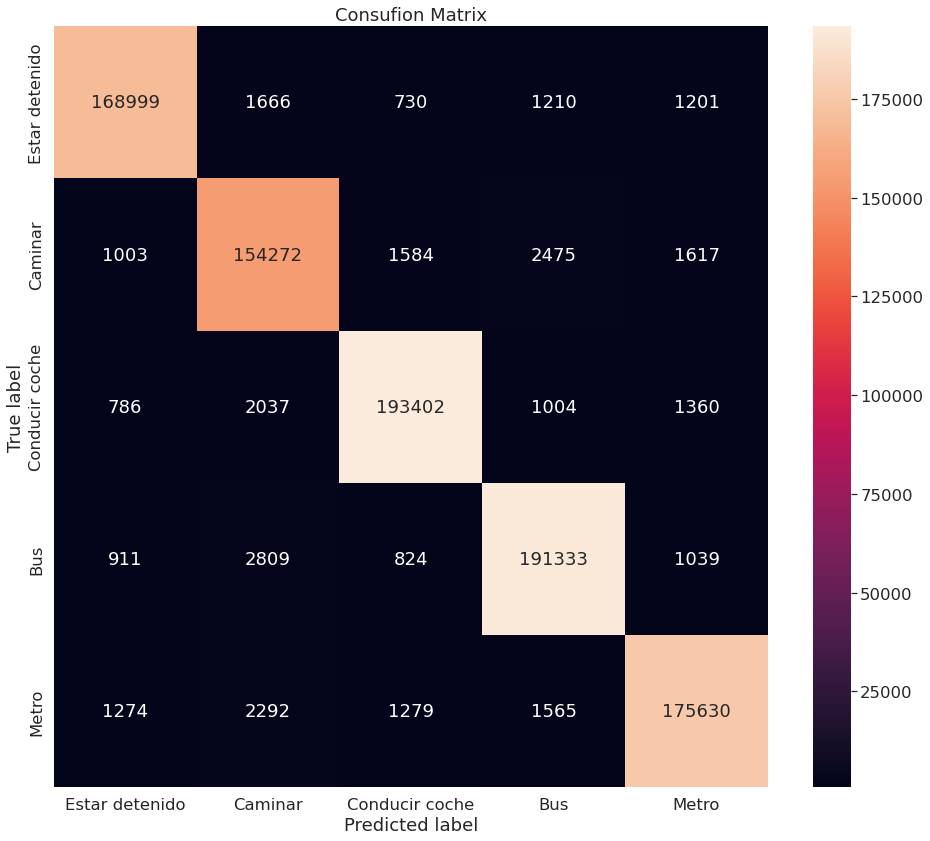

In [73]:
confusion_matrix = metrics.confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)

Labels=['Estar detenido', 'Caminar', 'Conducir coche', 'Bus', 'Metro']

plt.figure(figsize=(16,14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True,fmt='d')
plt.title('Consufion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show


In [74]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_true_labels, return_counts=True)

#Imprimir el resultado
for valor, conteo, label in zip(valores, conteos, Labels):
    print(f"Valor: {valor}, Cantidad: {conteo}, Actividad: {label}")

Valor: 0, Cantidad: 173806, Actividad: Estar detenido
Valor: 1, Cantidad: 160951, Actividad: Caminar
Valor: 2, Cantidad: 198589, Actividad: Conducir coche
Valor: 3, Cantidad: 196916, Actividad: Bus
Valor: 4, Cantidad: 182040, Actividad: Metro


# Exportamos el modelo

In [76]:
import joblib
# Guardamos el modelo entrenado
filename = 'Modelos/model_SHL.pkl' # Nombre del archivo donde se guardará el modelo
joblib.dump(model, filename) # Guardamos el modelo en un archivo

['Modelos/model_SHL.pkl']